# OCR Evaluation (Tesseract)

So sánh OCR accuracy bằng **Tesseract** trên các phương pháp scan/binarization.

## Phương pháp scan so sánh
1. **original** — vùng tương ứng trên ảnh gốc (vẫn méo perspective) — baseline
2. **warped_gray** — vùng crop trên ảnh warped, xám
3. **otsu** — Otsu thresholding
4. **adaptive** — Adaptive Gaussian threshold
5. **clahe_otsu** — CLAHE + Otsu
6. **color** — Color-preserving (background division)

## Cách chạy

1. Chạy cell **Đọc dữ liệu từ kaggle** để tải dữ liệu từ kaggle.
2. Chạy lần lượt các cell còn lại.

In [ ]:
%pip install -q pytesseract python-Levenshtein
!apt-get -qq install -y tesseract-ocr tesseract-ocr-vie tesseract-ocr-eng
!tesseract --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.1 MB/s eta 0:00:00
Selecting previously unselected package tesseract-ocr-vie.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-vie_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-vie (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-vie (1:4.00~git30-7274cfa-1.1) ...
tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [ ]:
import json
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytesseract
from Levenshtein import distance, ratio

## 1. Đọc data từ kaggle

In [ ]:
import os
from google.colab import files


!rm -rf ~/.cache/kaggle
!rm -rf /content/dataset

!kaggle datasets download -d tiendq/scanner --force
!unzip -q scanner.zip -d /content

In [ ]:
EVAL_DIR = Path('/content/dataset/test/eval_run')
WARPED_DIR = EVAL_DIR / 'warped'
TRANSFORMS_DIR = EVAL_DIR / 'transforms'
OCR_GT_PATH = EVAL_DIR / 'ocr_gt.json'
ORIGINAL_DIR = Path('/content/dataset/test')

RESULTS_CSV = EVAL_DIR / 'ocr_results_tesseract.csv'
SUMMARY_CSV = EVAL_DIR / 'ocr_summary_tesseract.csv'

ENGINE_NAME = 'tesseract'
TESS_LANG = 'vie+eng'
TESS_CONFIG = '--psm 6'

print('EVAL_DIR    :', EVAL_DIR)
print('ORIGINAL_DIR:', ORIGINAL_DIR)
print('TESS_LANG   :', TESS_LANG)

## 2. Đọc data từ drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# EVAL_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test/test_detection/eval_run')
# WARPED_DIR = EVAL_DIR / 'warped'
# TRANSFORMS_DIR = EVAL_DIR / 'transforms'
# OCR_GT_PATH = EVAL_DIR / 'ocr_gt.json'
# ORIGINAL_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test/test_detection')

# RESULTS_CSV = EVAL_DIR / 'ocr_results_tesseract.csv'
# SUMMARY_CSV = EVAL_DIR / 'ocr_summary_tesseract.csv'

# ENGINE_NAME = 'tesseract'
# TESS_LANG = 'vie+eng'
# TESS_CONFIG = '--psm 6'

# print('EVAL_DIR    :', EVAL_DIR)
# print('ORIGINAL_DIR:', ORIGINAL_DIR)
# print('TESS_LANG   :', TESS_LANG)

EVAL_DIR    : /content/drive/MyDrive/CV/pr/dataset/test/test_detection/eval_run
ORIGINAL_DIR: /content/drive/MyDrive/CV/pr/dataset/test/test_detection
TESS_LANG   : vie+eng


## 3. Load ground truth

In [ ]:
with open(OCR_GT_PATH, encoding='utf-8') as f:
    gt_data = json.load(f)

CROP_REGION = tuple(gt_data['crop_region'])
items = gt_data['items']
print(f'Ground truth có {len(items)} ảnh, crop_region = {CROP_REGION}\n')
for stem, info in items.items():
    print(f'  {stem}: {info["ground_truth"][:60]}...')

Ground truth có 18 ảnh, crop_region = (0.05, 0.06, 0.95, 0.16)

  z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26: I’ve always been keen on sport and very fit so a few years a...
  z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827142264_5ac4f8f41b14a8f38425b0c2e7bf576e: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827176964_651ecba060792771a088a276a71224c6: Thời gian Đầm thuận kiếm được. Đồng thời họ cũng hi vọng “mộ...
  2aOboQY0LBwLs4o8LQpYJ31H0OSflP7tBBHsTLTE: Output: chuyển thành thập phân ta tạo biến acc = 0 duyệt từ ...
  2aOboQY0LEFxDH3abPqjshfixAFuRAaJTAJ5BjiC: Hoa – Việt thân thiện đối với quân đội Tưởng Giới Thạch và v...
  2aOboQY0L8fcafZOXWcTbRm76XS8xGc87Tpt8AcK: Thực hiện kế hoạc rơve, từ tháng 6/1949 Pháp đưa nhiều vũ kh...
  z7722644494144_618dbae640d2900065f9

## 4. Hàm tiện ích

### 4.1. Crop & inverse map

In [ ]:
def warped_bbox_to_original_quad(bbox_warped, M):
    """bbox_warped = (x0, y0, x1, y1) trên ảnh warped → 4 điểm trên ảnh gốc."""
    x0, y0, x1, y1 = bbox_warped
    pts = np.array([
        [x0, y0], [x1, y0], [x1, y1], [x0, y1]
    ], dtype=np.float32).reshape(-1, 1, 2)
    M_inv = np.linalg.inv(np.asarray(M, dtype=np.float64))
    out = cv2.perspectiveTransform(pts, M_inv)
    return out.reshape(4, 2)


def crop_quad_bbox_on_original(img, quad):
    """Bounding box bao quanh quad trên ảnh gốc — GIỮ méo perspective."""
    quad = np.asarray(quad).reshape(4, 2)
    x_min, y_min = quad.min(axis=0)
    x_max, y_max = quad.max(axis=0)
    H, W = img.shape[:2]
    x_min = max(0, int(np.floor(x_min)))
    y_min = max(0, int(np.floor(y_min)))
    x_max = min(W, int(np.ceil(x_max)))
    y_max = min(H, int(np.ceil(y_max)))
    return img[y_min:y_max, x_min:x_max]

### 4.2. Các phương pháp binarization/enhancement

In [ ]:
def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()


def apply_otsu(img):
    gray = to_gray(img)
    _, out = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return out


def apply_adaptive(img, block_size=21, C=8):
    gray = to_gray(img)
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, C,
    )


def apply_clahe_otsu(img, clip_limit=2.0, tile_grid=(8, 8)):
    gray = to_gray(img)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    enhanced = clahe.apply(gray)
    _, out = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return out


def color_preserving_scan(img_bgr):
    """Background division — giữ màu, làm nền trắng đều."""
    if len(img_bgr.shape) == 2:
        img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2BGR)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    bg = cv2.dilate(gray, np.ones((7, 7), np.uint8))
    bg = cv2.medianBlur(bg, 21)
    bg_3ch = cv2.cvtColor(bg, cv2.COLOR_GRAY2BGR).astype(np.float32)
    diff = img_bgr.astype(np.float32) / np.maximum(bg_3ch, 1) * 255
    return np.clip(diff, 0, 255).astype(np.uint8)


def get_variant(name, warped_crop_bgr):
    if name == 'warped_gray':
        return to_gray(warped_crop_bgr)
    if name == 'otsu':
        return apply_otsu(warped_crop_bgr)
    if name == 'adaptive':
        return apply_adaptive(warped_crop_bgr)
    if name == 'clahe_otsu':
        return apply_clahe_otsu(warped_crop_bgr)
    if name == 'color':
        return color_preserving_scan(warped_crop_bgr)
    raise ValueError(f'Unknown variant: {name}')


VARIANTS = ['warped_gray', 'otsu', 'adaptive', 'clahe_otsu', 'color']
ALL_VARIANTS = ['original'] + VARIANTS

### 4.3. Tesseract OCR + Metric

In [ ]:
def run_tesseract(img):
    if img is None or img.size == 0:
        return ''
    if len(img.shape) == 2:
        rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    try:
        return pytesseract.image_to_string(rgb, lang=TESS_LANG, config=TESS_CONFIG)
    except Exception as e:
        print(f'  [tesseract error] {e}')
        return ''


def normalize(text):
    text = (text or '').replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def char_accuracy(pred, gt):
    return ratio(normalize(pred), normalize(gt))


def cer(pred, gt):
    p, g = normalize(pred), normalize(gt)
    if not g:
        return 0.0
    return distance(p, g) / len(g)


def word_accuracy(pred, gt):
    p_words = normalize(pred).lower().split()
    g_words = normalize(gt).lower().split()
    if not g_words:
        return 0.0
    pool = list(p_words)
    correct = 0
    for w in g_words:
        if w in pool:
            correct += 1
            pool.remove(w)
    return correct / len(g_words)


def all_metrics(pred, gt):
    return {
        'char_acc': char_accuracy(pred, gt),
        'cer': cer(pred, gt),
        'word_acc': word_accuracy(pred, gt),
    }

## 5. Helper: chuẩn bị các crop cho 1 ảnh

In [ ]:
def find_original(stem):
    for ext in ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'):
        p = ORIGINAL_DIR / f'{stem}{ext}'
        if p.exists():
            return p
    matches = list(ORIGINAL_DIR.glob(f'{stem}.*'))
    return matches[0] if matches else None


def prepare_crops(stem, info):
    """Trả về dict {variant_name: image} cho 1 ảnh."""
    crops = {}

    warped_path = WARPED_DIR / f'{stem}.jpg'
    warped = cv2.imread(str(warped_path))
    if warped is None:
        return None

    crop_pixel = info['crop_pixel']
    x0, y0, x1, y1 = crop_pixel
    warped_crop = warped[y0:y1, x0:x1]

    # original via M^-1
    transform_path = TRANSFORMS_DIR / f'{stem}.json'
    if transform_path.exists():
        with open(transform_path) as f:
            tdata = json.load(f)
        M = np.array(tdata['M'], dtype=np.float64)
        original_path = find_original(stem)
        if original_path is not None:
            original = cv2.imread(str(original_path))
            quad = warped_bbox_to_original_quad((x0, y0, x1, y1), M)
            crops['original'] = crop_quad_bbox_on_original(original, quad)

    for vname in VARIANTS:
        crops[vname] = get_variant(vname, warped_crop)

    return crops

## 6. Chạy evaluation

Loop qua từng ảnh × từng variant → DataFrame.

In [ ]:
rows = []
predictions_cache = {}

for stem, info in items.items():
    print(f'\n=== {stem} ===')
    gt_text = info['ground_truth']

    crops = prepare_crops(stem, info)
    if crops is None:
        print('  [skip] không chuẩn bị được crop')
        continue
    predictions_cache[stem] = {'crops': crops, 'preds': {}}

    for variant in ALL_VARIANTS:
        img = crops.get(variant)
        if img is None or img.size == 0:
            print(f'  [skip] {variant}: empty crop')
            continue

        pred = run_tesseract(img)
        metrics = all_metrics(pred, gt_text)
        rows.append({
            'stem': stem,
            'variant': variant,
            'engine': ENGINE_NAME,
            'pred': pred.strip(),
            'gt': gt_text,
            **metrics,
        })
        predictions_cache[stem]['preds'][variant] = pred
        print(f"  {variant:14s} char_acc={metrics['char_acc']:.3f}  cer={metrics['cer']:.3f}  word_acc={metrics['word_acc']:.3f}")

df = pd.DataFrame(rows)
df.to_csv(RESULTS_CSV, index=False)
print(f'\nLưu kết quả → {RESULTS_CSV}')
df.head(20)


=== z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26 ===
  original       char_acc=0.927  cer=0.139  word_acc=0.909
  warped_gray    char_acc=0.916  cer=0.169  word_acc=0.909
  otsu           char_acc=0.952  cer=0.074  word_acc=0.848
  adaptive       char_acc=0.959  cer=0.062  word_acc=0.864
  clahe_otsu     char_acc=0.953  cer=0.086  word_acc=0.909
  color          char_acc=0.927  cer=0.145  word_acc=0.924

=== z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd ===
  original       char_acc=0.365  cer=0.883  word_acc=0.000
  warped_gray    char_acc=0.351  cer=0.778  word_acc=0.030
  otsu           char_acc=0.389  cer=0.747  word_acc=0.030
  adaptive       char_acc=0.322  cer=0.938  word_acc=0.000
  clahe_otsu     char_acc=0.390  cer=0.728  word_acc=0.030
  color          char_acc=0.329  cer=0.858  word_acc=0.000

=== z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3 ===
  original       char_acc=0.316  cer=0.840  word_acc=0.000
  warped_gray    char_acc=0.300  cer=0.815  word_acc=0.061
  o

,stem,variant,engine,pred,gt,char_acc,cer,word_acc
0,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,original,tesseract,I’ve always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.927171,0.139466,0.909091
1,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,warped_gray,tesseract,I've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.915629,0.169139,0.909091
2,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,otsu,tesseract,lve always been keen on sport and very fil so ...,I’ve always been keen on sport and very fit so...,0.951825,0.074184,0.848485
3,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,adaptive,tesseract,I've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.958944,0.062315,0.863636
4,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,clahe_otsu,tesseract,I've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.952518,0.086053,0.909091
5,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,color,tesseract,I've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.927374,0.145401,0.924242
6,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,original,tesseract,p kg cóc vhéc đeuải chếu hcoếc Âeouye ded ac f...,Điều khoản liên quan tới chương trình máy chươ...,0.365169,0.882716,0.000000
7,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,warped_gray,tesseract,Me ee ee ere\n\nRisin Woon Bien qoan ác Adda i...,Điều khoản liên quan tới chương trình máy chươ...,0.350515,0.777778,0.030303
8,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,otsu,tesseract,eS a ae pe Se ee\n\nđế kh»an No quan dc ÁLag n...,Điều khoản liên quan tới chương trình máy chươ...,0.388715,0.746914,0.030303
9,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,adaptive,tesseract,"Sư ""“ Mie ASUA Nam bon Lưu +4 dạn BH pH .\n\nN...",Điều khoản liên quan tới chương trình máy chươ...,0.321839,0.938272,0.000000


## 7. Bảng tổng hợp

In [ ]:
variant_order = ['original', 'warped_gray', 'otsu', 'adaptive', 'clahe_otsu', 'color']

summary = df.groupby('variant')[['char_acc', 'cer', 'word_acc']].mean().round(4)
summary = summary.reindex(variant_order)
summary['engine'] = ENGINE_NAME
summary = summary.reset_index()[['engine', 'variant', 'char_acc', 'cer', 'word_acc']]

summary.to_csv(SUMMARY_CSV, index=False)
print(f'Lưu summary → {SUMMARY_CSV}\n')
summary

Lưu summary → /content/drive/MyDrive/CV/pr/dataset/test/test_detection/eval_run/ocr_summary_tesseract.csv



,engine,variant,char_acc,cer,word_acc
0,tesseract,original,0.5218,0.8133,0.4493
1,tesseract,warped_gray,0.5914,0.5401,0.4342
2,tesseract,otsu,0.5124,0.6270,0.2627
3,tesseract,adaptive,0.6122,0.6054,0.4596
4,tesseract,clahe_otsu,0.6120,0.5604,0.4760
5,tesseract,color,0.6030,0.6241,0.4885


In [ ]:
# Pivot dễ đọc + đánh dấu best
best_variant = summary.set_index('variant')['char_acc'].idxmax()
print(f'Phương pháp tốt nhất theo char_acc: {best_variant}')
print()
print(summary.to_string(index=False))

Phương pháp tốt nhất theo char_acc: adaptive

   engine     variant  char_acc    cer  word_acc
tesseract    original    0.5218 0.8133    0.4493
tesseract warped_gray    0.5914 0.5401    0.4342
tesseract        otsu    0.5124 0.6270    0.2627
tesseract    adaptive    0.6122 0.6054    0.4596
tesseract  clahe_otsu    0.6120 0.5604    0.4760
tesseract       color    0.6030 0.6241    0.4885


## 8. Biểu đồ so sánh

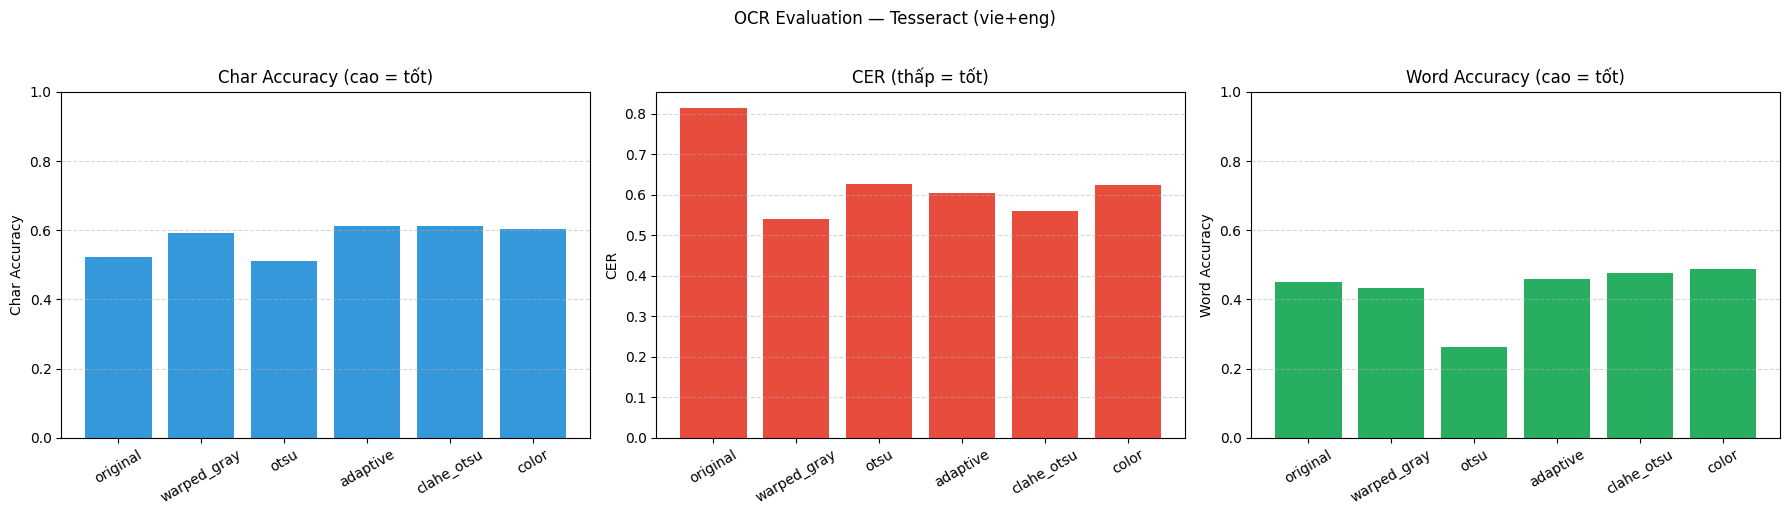

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

summary_idx = summary.set_index('variant').reindex(variant_order)

axes[0].bar(summary_idx.index, summary_idx['char_acc'], color='#3498db')
axes[0].set_title('Char Accuracy (cao = tốt)')
axes[0].set_ylabel('Char Accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(summary_idx.index, summary_idx['cer'], color='#e74c3c')
axes[1].set_title('CER (thấp = tốt)')
axes[1].set_ylabel('CER')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(summary_idx.index, summary_idx['word_acc'], color='#27ae60')
axes[2].set_title('Word Accuracy (cao = tốt)')
axes[2].set_ylabel('Word Accuracy')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle(f'OCR Evaluation — Tesseract ({TESS_LANG})', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 9. Trực quan từng ảnh

6 panel cho 6 variant + in text dự đoán.

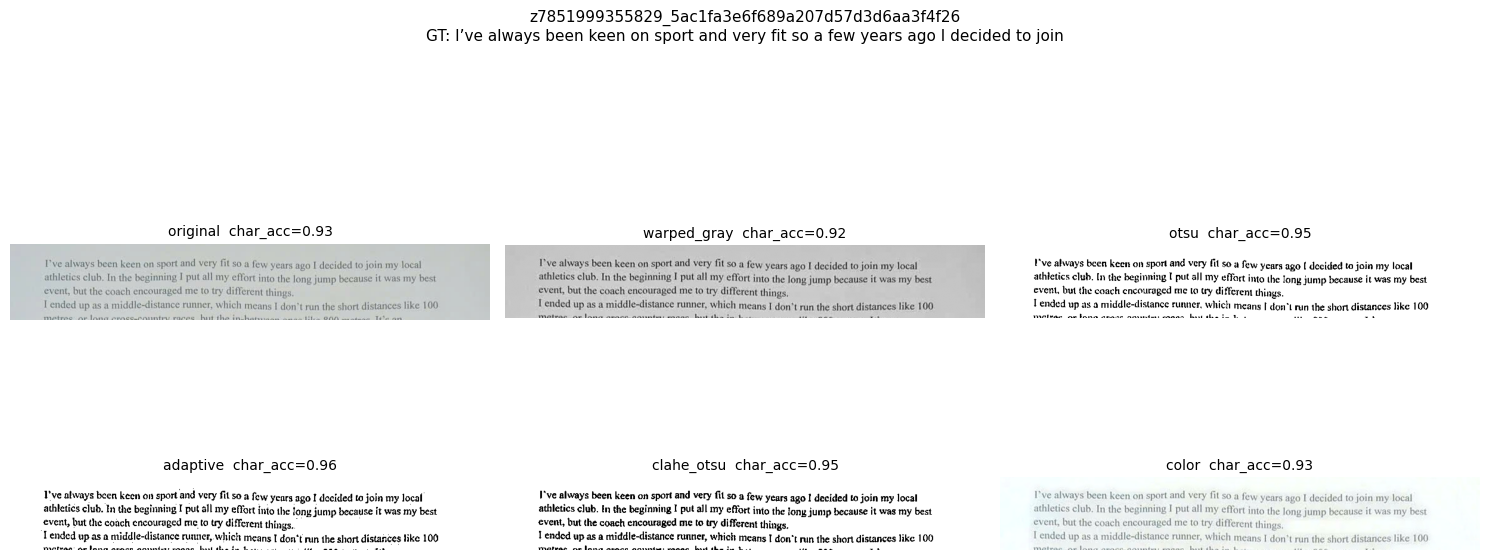

=== z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26 ===
GT  : I’ve always been keen on sport and very fit so a few years ago I decided to join my local athletics club. In the beginning I put all my effort into the long jump becasue it was my best avent, but the coach encouraged me to try different things. I ended up as a middle-distance runner, which means I don’t run the short distances like 100
  original      : I’ve always been keen on sport and very fit so a few years ago I decided to join my local | athletic
  warped_gray   : I've always been keen on sport and very fit so a few years ago I decided to join my local | athletic
  otsu          : lve always been keen on sport and very fil so a few years ago [ decided to join my local | athietics
  adaptive      : I've always been keen on sport and very fit so a few years ago I decided ta join my local | athletic
  clahe_otsu    : I've always been keen on sport and very fit so a few years ago I decided to join my local | athletic
  col

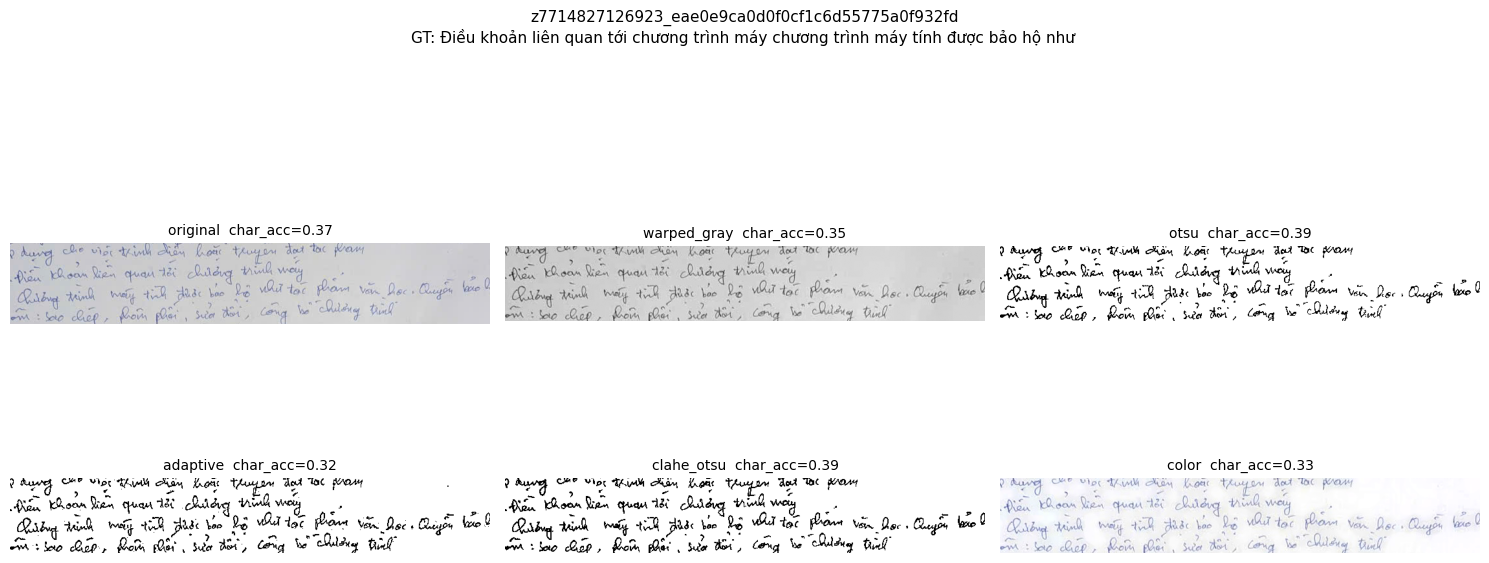

=== z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : p kg cóc vhéc đeuải chếu hcoếc Âeouye ded ac fray | vn VÕ se then `... trial wet, % : | Quảng Minh ấ
  warped_gray   : Me ee ee ere |  | Risin Woon Bien qoan ác Adda ink wei, ? |  | Qing ind wey WR prac woo Để Vt toe Pr
  otsu          : eS a ae pe Se ee |  | đế kh»an No quan dc ÁLag nied wong - |  | Rising Wind way 4B pac keo Dg Wat te
  adaptive      : Sư "“ Mie ASUA Nam bon Lưu +4 dạn BH pH . |  | Nin roan Sian qua đất Suddug vainll wig c _ | Ribu Mi
  clahe_otsu    : Mag SOO << | Ran hoon W2 quan Tất 24. nin, woot ˆ |  | động VẢ sp ƠI diác le Độ BN đạc gen và. Bạc, 
  color         : ƯA; * TU Th Sun kone ee Tiga GN RAE |  | Dei eon Yer pea ASE 914g in vien) + |  | Rearing Wink Waly 



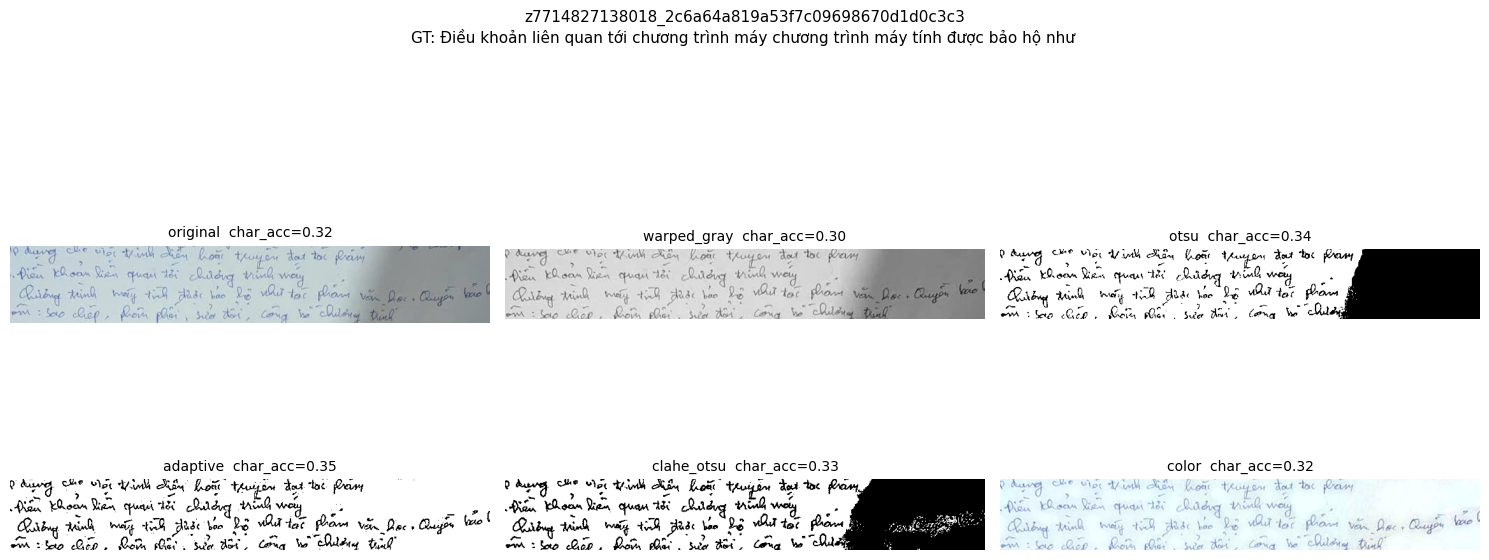

=== z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3 ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : ng Có eC Mth Ny Choke tuum tat toe Peing | “ÔNG KÔso^ ÖcA quợa đế Diddvg vied weiy | đA¿g ÂỔ kết +2 
  warped_gray   : ie eon ACH ae (QUÁ v0 c ải | Dida Woon Yer quan 18 AMuddvg rin, wey de |  | Qrbry Mil wate AB drde V
  otsu          : vựng CÓ y Viết Vui châu ba Aegan dot Toc fray | Dida Khoon Be quan Tết iddug tnd, wey X |  | đang VỐ
  adaptive      : Peg SY Vet laws Ain’ nos TVuueae de lát [Zvưu | RES eon Dien pete IEE Diddg ain wey ¬ | đang Mink hấ
  clahe_otsu    : PG Sek Maes Aa Ko eo Bek “oe roan |  | Tian hear Mien quan đốc Sddig inl wey l | ng Min Hát GA] Qhác
  color         : ƯA a Migc Mae Keone tion Bot toe ray, |  | Aisa Hoon Veen pra tk Mddeg rol wety . | Raddy ind by WDD



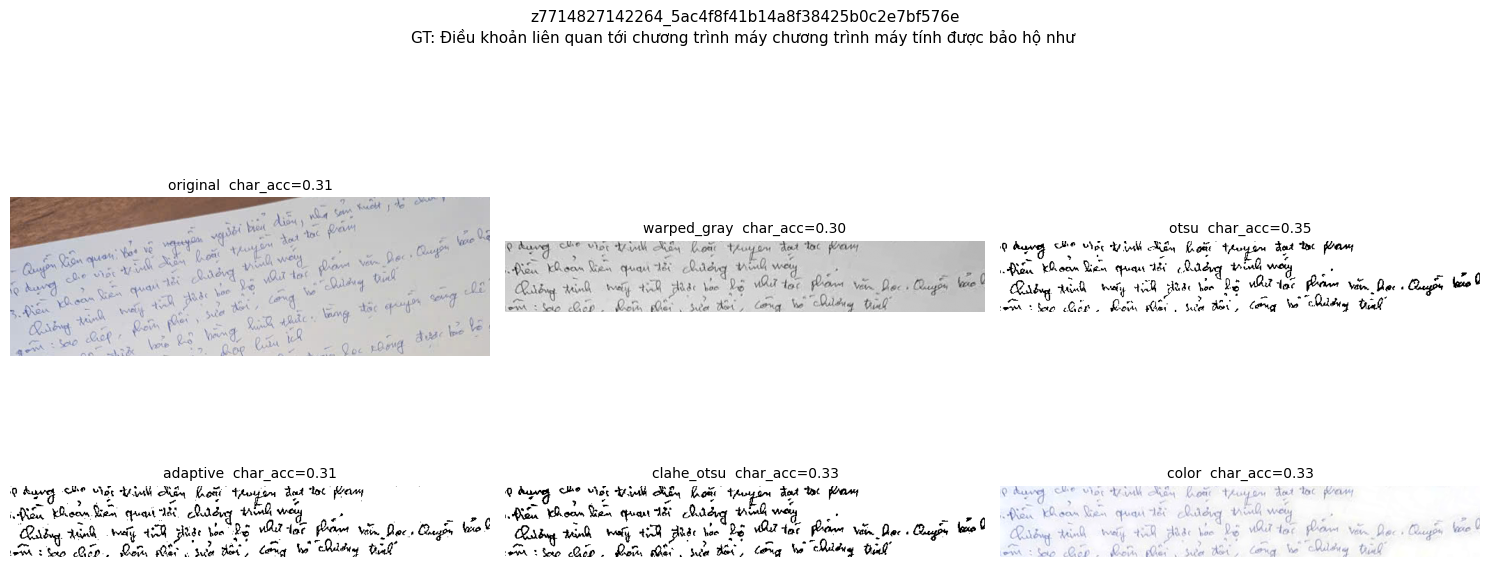

=== z7714827142264_5ac4f8f41b14a8f38425b0c2e7bf576e ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : = nh | ie ker nee ees `. ne là | . xa. án âu doc PO" cá | ` 2 ek tee od suing we | đàng quà VU s we 
  warped_gray   : Gy UN CN MOR oi b0 02 09 la | Thy `... vind wety 5 - | đang QUÁ tới AR rar oo Bg WA dạc dnt iin Dec 
  otsu          : 9 Sựng VÔ Sun Mu chân koất W@eibes ded Jc hang | Den foam ian poo ĐÁ Qadrer wind, ven - . | Qartg Wa
  adaptive      : sàn và Mer at olan ott Ty BoA đạc Mưa» |  | Ree Brean ties quai ak Qadg wel wey „ ~ | đang Ho ety VẾ
  clahe_otsu    : lân) và et Tit oan lo. Vegan dot et fray |  | Rin hoon ten twat it Dodgy tral wey có S, |  | Bisby e
  color         : g at `. wee Muh Aan ow tees ‘ded Toc pany |  | RE Woon Gem quan tt cMadig el wely |  | đang VÉ tới W



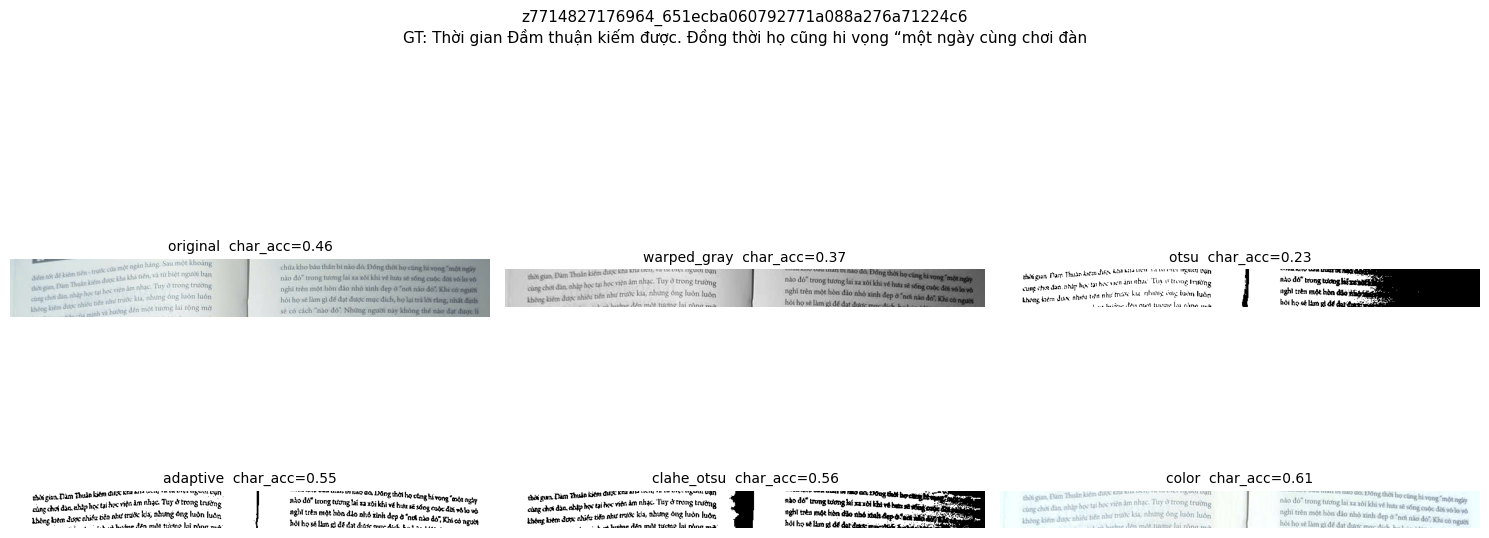

=== z7714827176964_651ecba060792771a088a276a71224c6 ===
GT  : Thời gian Đầm thuận kiếm được. Đồng thời họ cũng hi vọng “một ngày cùng chơi đàn, nhập học tại viện âm nhạc. Tuy ở trong trường nào đó” trong tương lai xa xôi khi về hưu sẽ sống cuộc đời vô lo vô không kiếm được nhiều tiền như trước kia nhưng ông luôn luôn nghĩ một hòn đảo nhỏ xinh đẹp ở “nơi nào đo”. Khi có người hỏi họ sẽ làm gì để đạt được
  original      : ——_ | mồ hàng, Sau một khoảng. | ei gan, Din Than bt bạn háến và từ biệt người bạn II | Tùng coi đàn
  warped_gray   : thời gian, Dàm Thuần kits bọc viên âm nhạc. Tuy ở trong trường, Ï ea engi | không kiếm được S886 204
  otsu          : thế gan Marr Than bres "".......` ì eng mg | kháng kiếm dư. Tóc s3 - An nà tan Hà sàng ca
  adaptive      : vi cina. Đàm Thuận kiếm GƯỚC kes 6 0 ONH ge eng thet ha ting o | oe mehdp hide vies Am nhac Tey Stro
  clahe_otsu    : vã gan Dàm Thuần kiếm đMỚ XI ee ne ea nit Beep `.“ | hp bạc GiÖe vn wha. THY Song eng nào de" hong t
  color  

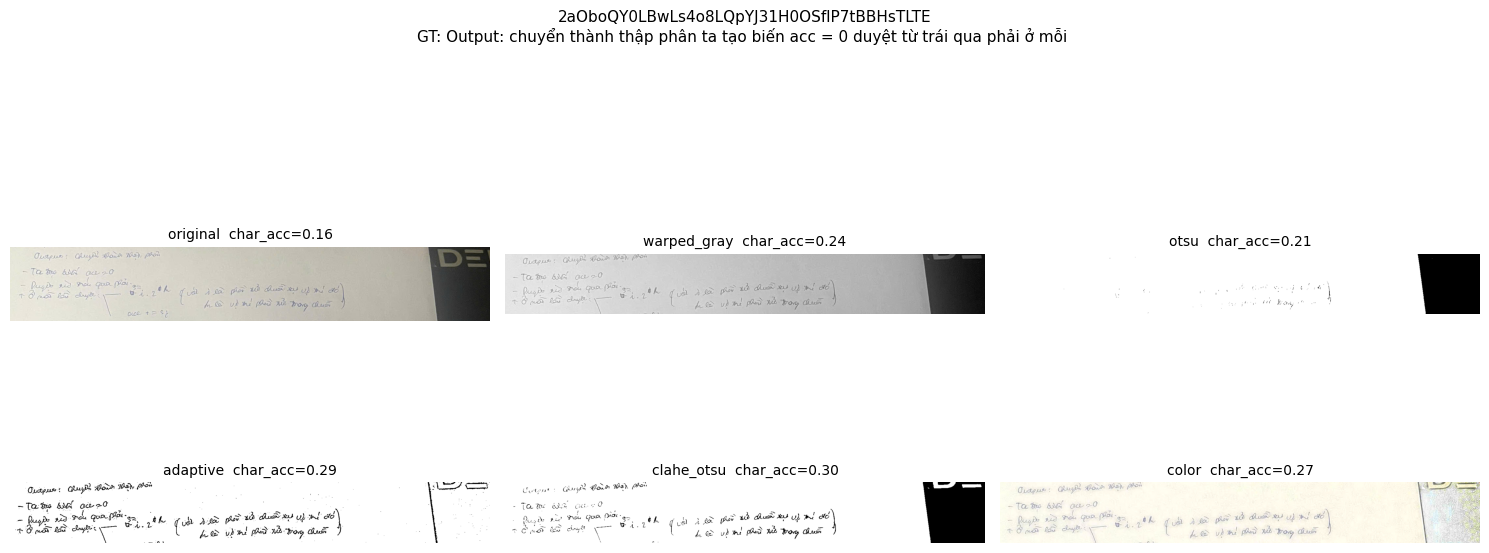

=== 2aOboQY0LBwLs4o8LQpYJ31H0OSflP7tBBHsTLTE ===
GT  : Output: chuyển thành thập phân ta tạo biến acc = 0 duyệt từ trái qua phải ở mỗi lần duyệt
  original      : sa #U (7) nl! Xe | a ce 3
  warped_gray   : i {L tao) LÍ ) % We } | us Bod 225 ov
  otsu          : 1 oe ae pot « | | ¬  F frene,
  adaptive      : Ởuy/et Ch 4foSm TÊỆN /02Ẻ " Nat | ~ Ta to ast gee a0 + - =~ tog . | - Day 123 ma, GAP ss the (@ Deed
  clahe_otsu    : Cote) Chy® Oona Wah prom —_ | - 1@œW ÁWA Góc zỞ |  | 7 a fo ioe a —~ t ‘ |  | Duy see Hee FORM Ge ek
  color         : 2w 1 — — | Cups, Cay Worm Wer. PO” | T hiệp |  | xảy ey eee |  | ~Tatee BA aero „ A ky | ae | N sờ O



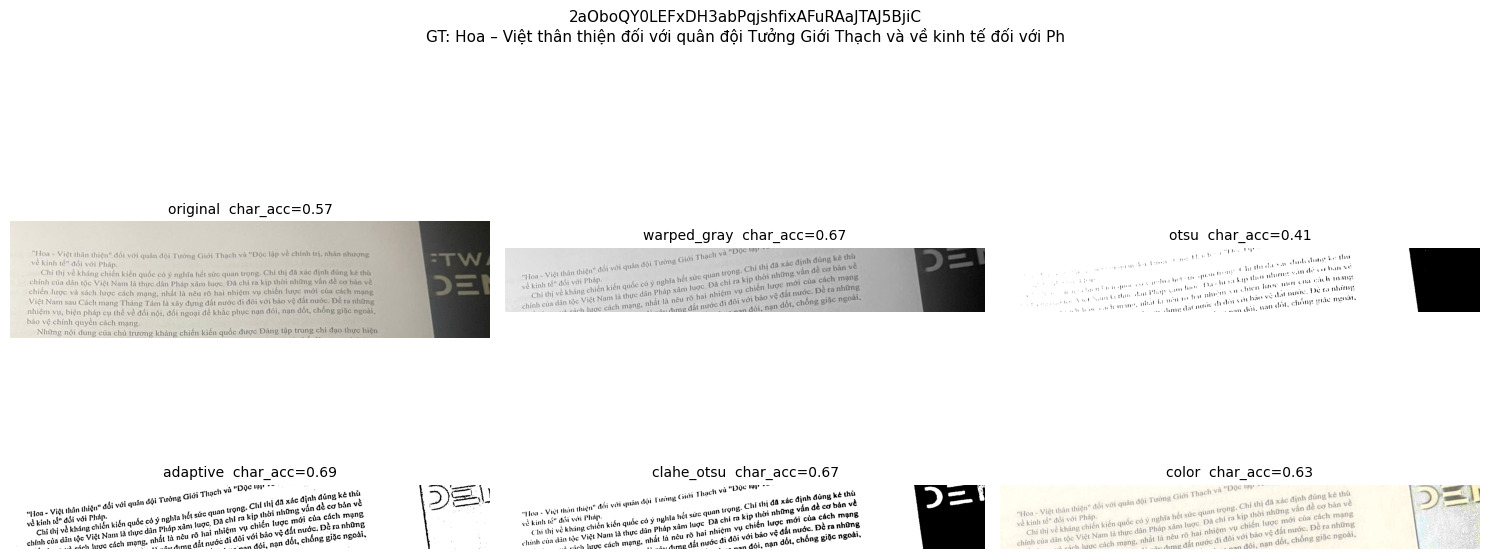

=== 2aOboQY0LEFxDH3abPqjshfixAFuRAaJTAJ5BjiC ===
GT  : Hoa – Việt thân thiện đối với quân đội Tưởng Giới Thạch và về kinh tế đối với Pháp Chỉ thị về kháng chiến kiến quốc có ý nghĩa hết sức quan trọng. Chỉ thị đã xác định đúng kẻ thù chính của dân tộc Việt Nam là thực dan Pháp xâm lược. Đã chỉ ra kịp thời những vấn đề cơ bản về lược cách mạng, nhất là nêu rõ hai nhiệm vụ chiến lược mới của cách mạng đất nước đi đôi với bảo vệ đất nước. Đề ra những đói, nạn dốt, chống giặc ngoài
  original      : \ : t Thạch và "Độc lập về chính trị, nhãn nhượng | I ii ối với quân đội Tướng Giới Thạch | Phar | C
  warped_gray   : | | | quan agi Tong GiGi THIS , "DOC PE | 4 Phát | HTD. gn que e830 ta hết sức quan trOẾ Chí thị đã 
  otsu          : | | | "¬..... ¬ PA | , cứng | | gua et ¬..... của hi dư t Gunde ding be the | - wee bị Hhn dạn Phát 
  adaptive      : "Ea « Việt thân thiện" đối với quân đội 'Tưởn§ Giới Thạch về — - | về kinh tế" đối với Pháp: ; :oh đ
  clahe_otsu    : “Hoa - Việt hàn thiện" 

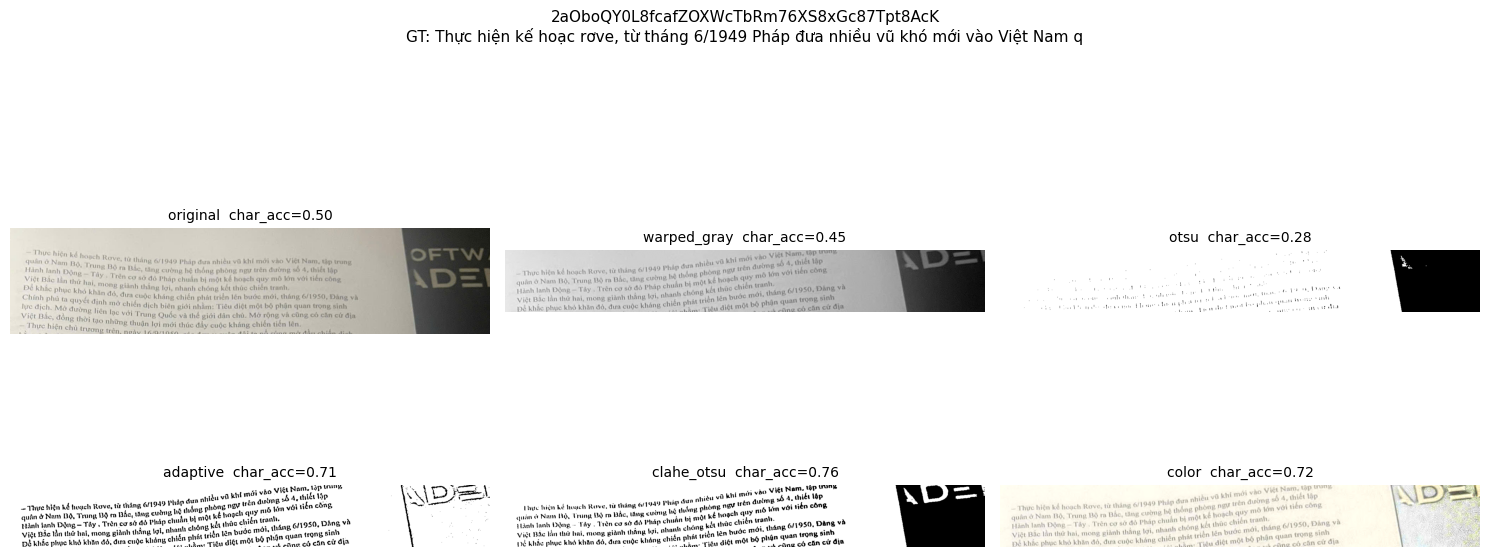

=== 2aOboQY0L8fcafZOXWcTbRm76XS8xGc87Tpt8AcK ===
GT  : Thực hiện kế hoạc rơve, từ tháng 6/1949 Pháp đưa nhiều vũ khó mới vào Việt Nam quân ở Nam Bộ, Trung Bộ ra Bắc, tăng cường hệ thống phòng ngự trên đường số 4, thiết lập Hành lang Đông – Tây. Trên cơ sở đó Pháp chuẩn bị một kế hoạch quy mô lớn với tiến công Việt Bắc lần thứ hai, mong giành thắng lợi, nhanh chóng kết thúc chiến tranh. Để khắc phục khó khăn đó, đưa cuộc kháng chiến phát triển lên bước mới, tháng 6/1950, Đảng và. Tiêu diệt một bộ phận quan trọng sinh có căn cứ địa
  original      : = In HỘ ra t a athe pl vỉ Fr 4. thiết { | h ì i Lrên cơ sở đỏ Pháp chuin bj mot ké! h quy mô lớn với
  warped_gray   : t \ ( T ® : | ' Ị i t tkế Í Vệ | 101 \ t hién tar | ; A \ hanh chon kết 0! fe ¡. thất 6/1950, Đăng V
  otsu          : ¡ ` 1 ì %, l | : : ‘ \ rol ¬ | to , ' ho oe | ‘ ' ' Hắc TH vi " ¬ copa Peat | : ¬¬ anh haar borat ¬ 
  adaptive      : đi „ 21 tế | —~ Thực hiện kế hoạch Rơve, từ thẳng 6/1942 pháp đưa nhiều vũ khi mới vie VI

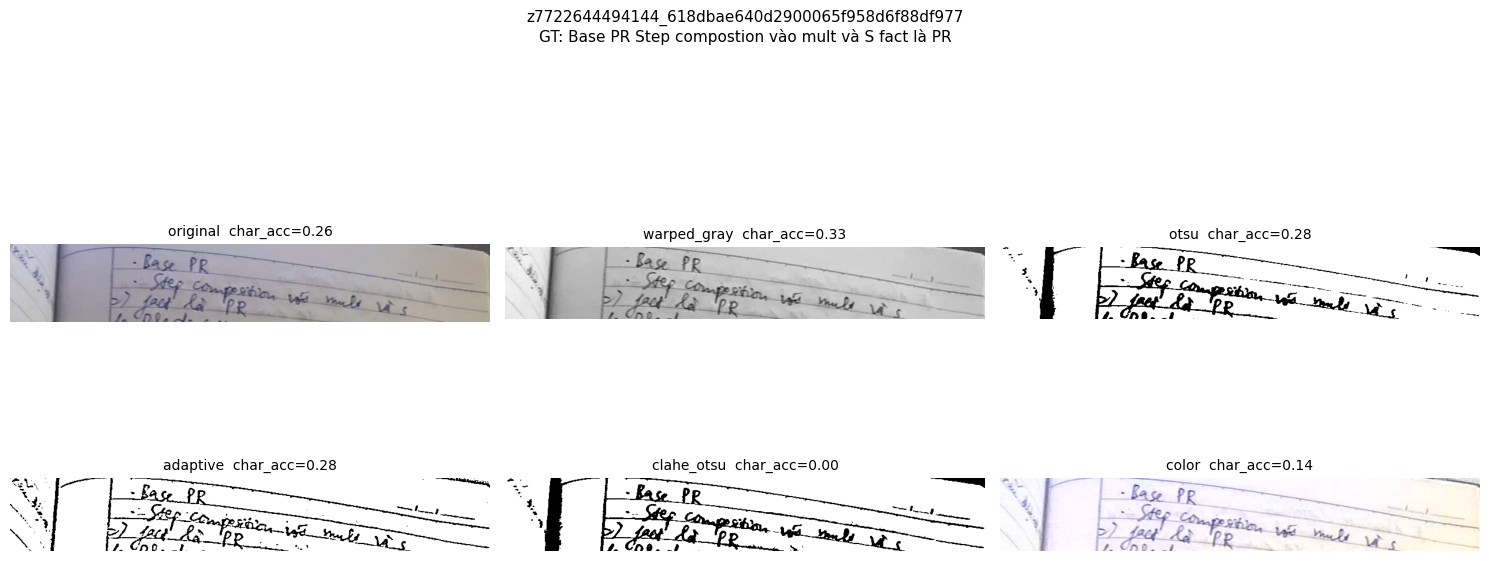

=== z7722644494144_618dbae640d2900065f958d6f88df977 ===
GT  : Base PR Step compostion vào mult và S fact là PR
  original      : S05 k Se | i % ca =“—~« = \ | ` : SS ——— = . | WCAG. 2.7 eee hoe +
  warped_gray   : ‘et ee | tine —* WE ey VÀ —
  otsu          : “Le co ca | yg na 4 Tờ Te
  adaptive      : Rel pee [te EE=. | ` + Sep - Ae ert : = | N | 22/20 ke pp en XẬT
  clahe_otsu    : 
  color         : ì BE F eee



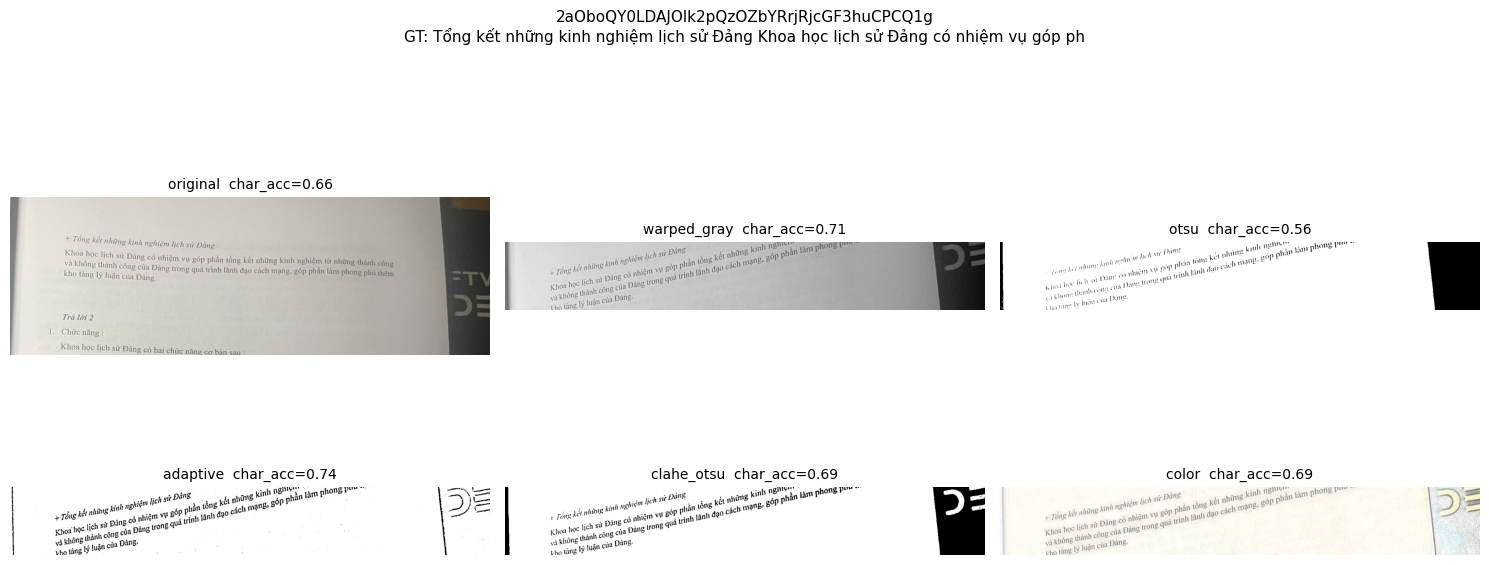

=== 2aOboQY0LDAJOlk2pQzOZbYRrjRjcGF3huCPCQ1g ===
GT  : Tổng kết những kinh nghiệm lịch sử Đảng Khoa học lịch sử Đảng có nhiệm vụ góp phần tổng kết những kinh và không thành công của Đảng trong quá trình lãnh đạo cách mạng, góp phần làm kho tàng lý luận của Đảng
  original      : + Tong két những kinh nghiệm lic h sử Đảng | i Nae k ae ghiệm từ những thành công | Khoa học lịch sử
  warped_gray   : Tong kết nhữHẽ kinh nghiệm lịch 3 pang | 5 a tO ê mg kinh neers | Khoa hoe lịch sử Đảng °° nhiệm vw 
  otsu          : Tìm eg ees. tình pete! hich ste Pans | ‘ ân 1Ô ề any kinh ngày | Khóa bee lịch sử Đang €9 nhiệm VỀ p
  adaptive      : + Tổng kết nhữnš kinh nghiệm lịch sử pang , inh neh |  | . ữ ngh |  | Khoa học lịch sử Đảng có nhiệm
  clahe_otsu    : L rồng kết nhữnể kinh nghiềt lịch sử Đảng kinh NB | % a tổ 4, phi inh 9 vo |  | Khoa hee lịch sử pan
  color         : + Tổng kết nhữHế kinh nghiêm lịch Sử pang 4 kinh nen | x ữn o2 v4 |  | Khoa hoc lịch sử DANE có nhiệ



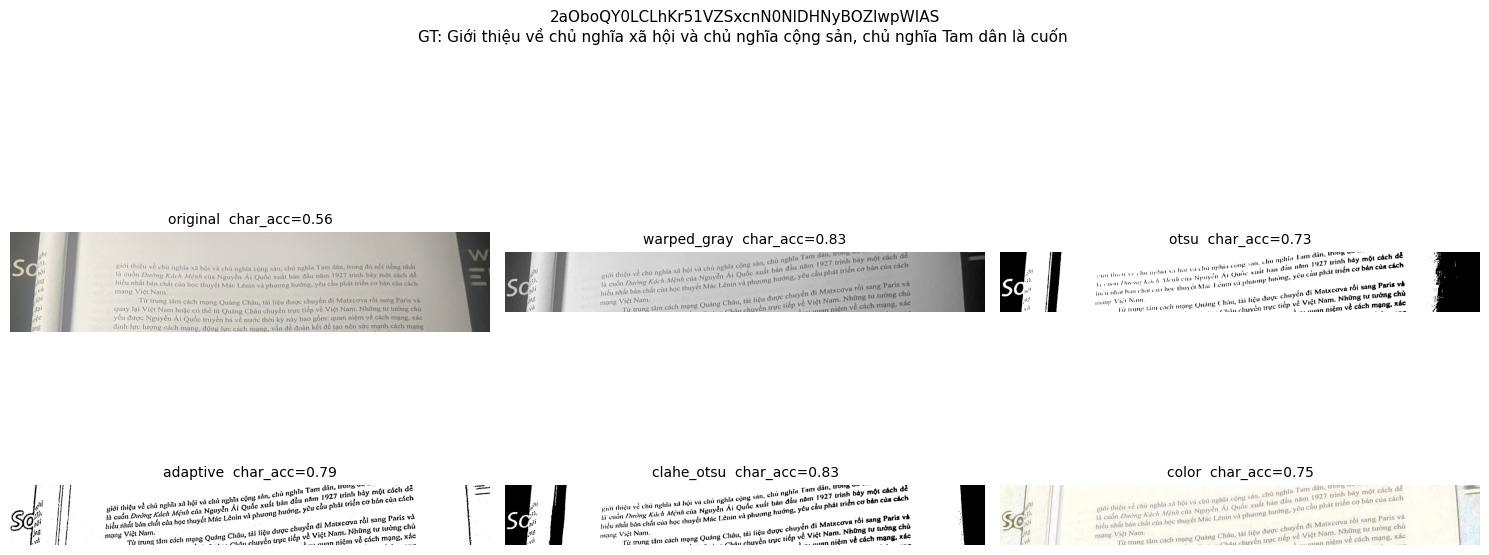

=== 2aOboQY0LCLhKr51VZSxcnN0NlDHNyBOZlwpWIAS ===
GT  : Giới thiệu về chủ nghĩa xã hội và chủ nghĩa cộng sản, chủ nghĩa Tam dân là cuốn Đường Kách Mệnh của Nguyễn Ái Quốc xuất bản đầu năm 1927 trình bày một cách dễ hiểu nhất bản chất của học thuyết Mác Lênin và phương hướng yêu cầu phát triển cơ bản của cách mạng Việt Nam Từ trung tâm cách mạng Quảng Chây, tài liệu được chuyển đi Matxcơva rồi sang Paris và chuyển trực tiếp về Việt Nam. Những tư tưởng chú niệm về cách mạng xác
  original      : | xhĩa Tam dân, trong đó nổi tiếng nhất ` | 3)» | giới thiệu về chủ nghĩa xã hội và chủ nghĩa cộng s
  warped_gray   : gi | a) giới thiệu về chủ nghĩa xã hội vá chủ nghĩa côn san, chu nghĩa Tam dân: oe i tho ee alee _ |
  otsu          : nl | ae voor acu ve edn những sả HỘI VÀ chủ nghĩa cone săn, chữ nghìn Tam dân: (rome a es | @.. là c
  adaptive      : sl | | s | b4) giới thiệu về chủ nghĩa xã hội và chủ n shia cone gắn, chủ nghĩa Tam dẫn. ON er — .-:
  clahe_otsu    : ch | a: ph” thiện vẻ chủ n

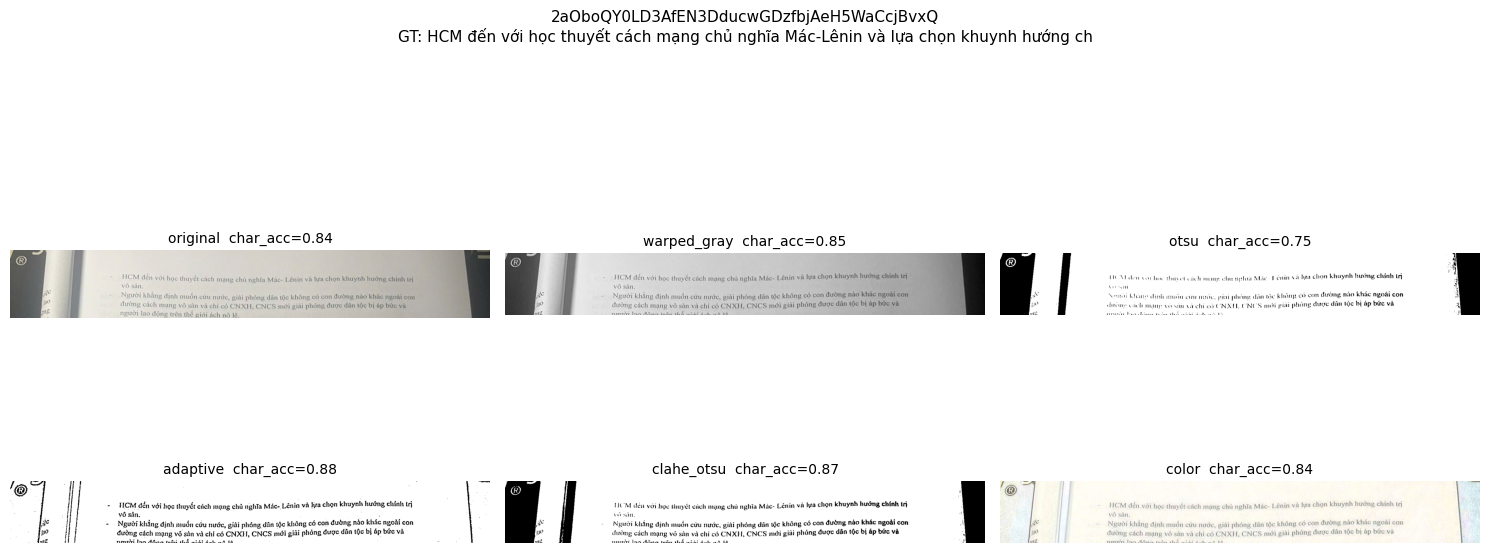

=== 2aOboQY0LD3AfEN3DducwGDzfbjAeH5WaCcjBvxQ ===
GT  : HCM đến với học thuyết cách mạng chủ nghĩa Mác-Lênin và lựa chọn khuynh hướng chính trị vô sản.  Người khẳng định muốn cứu nước, giải phóng dân tộc không có con đường nào khác ngoài con đường cách mạng vô sản và chỉ có CNXH, CNCS mới giải phóng được dân tộc bị áp bức và
  original      : i "a | @ 4 | | HCM đến với học thuyết cách mang chủ nghĩa Mác- Lênin và lựa chọn khuynh hướng chính 
  warped_gray   : ® 4 | a |  | HCM dén với học thuyết cách mạng chủ nghĩa Mác- Lênin và lựa chọn khuynh hướng chính tr
  otsu          : ® 4 | my |  | ĐC XI den vắt học thấy et cách mang cher aghia Mace) énin va kes chon khuynh hudéng ch
  adaptive      : - HM đến với học thuyết cách mang chủ nghĩa Mác-, Lénin và lựa chọn khuynh hướng chính trị | v6 san.
  clahe_otsu    : TCM den với học thuyết cách mạng chủ nghĩa Mác- Lênin và lựa chọn khuynh hướng chính trị : | ve sin,
  color         : / L ! L3 NT | @ ‘ e |  | i -__. HCM đến với học thuyết cách m

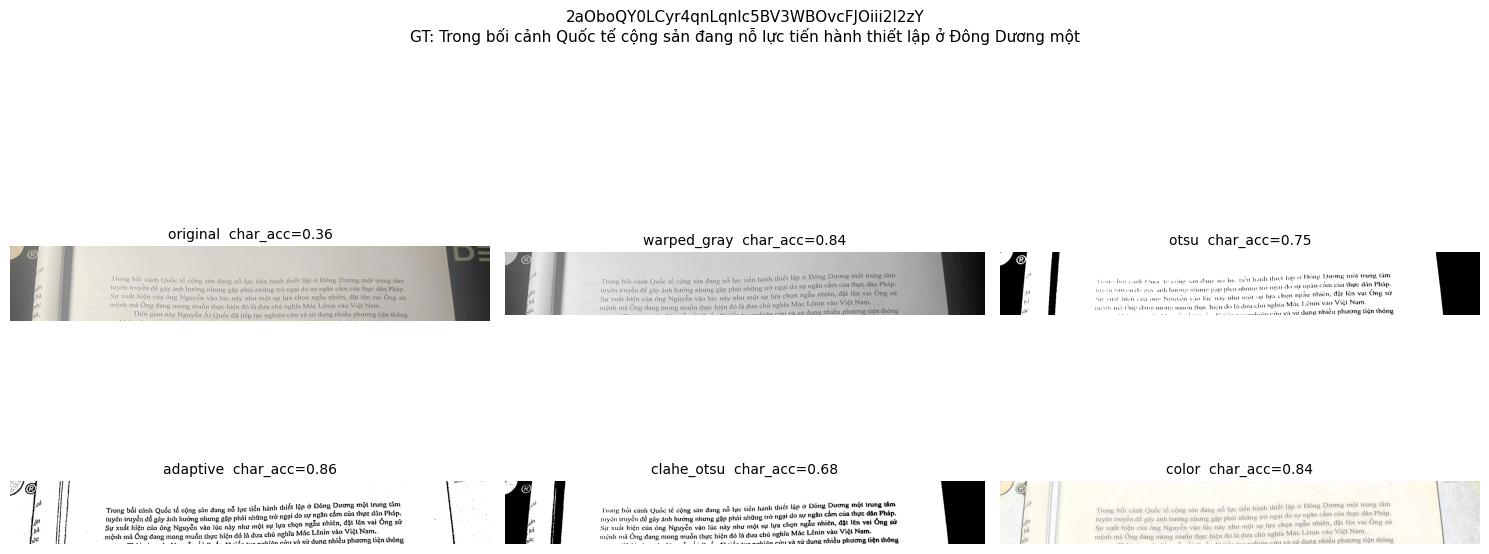

=== 2aOboQY0LCyr4qnLqnlc5BV3WBOvcFJOiii2I2zY ===
GT  : Trong bối cảnh Quốc tế cộng sản đang nỗ lực tiến hành thiết lập ở Đông Dương một trung tâm tuyên truyền để gây ảnh hưởng nhung gặp phải những trở ngại do sự ngăn cấm của thực dân Pháp. Sự xuất hiện của ông Nguyễn vào kucs này như một sự lựa chọn ngẫu nhiên, đặt lên vai Ông sứ mệnh mà Ông đang mong muốn thực hiện đó là đưa chủ nghĩa Mác Lênin vào Vieeth Nam và sử dụng nhiều phương tiện thông
  original      : vÓ | in | 7 | | nrc | pul | rc | Dr | tu ee | : x | = en : | hà tr. 7 | : Š ni | = uat a ụ | énl ì :
  warped_gray   : @ | có | Trong bối cảnh Quốc tế cộng sản đang nỗ lực tién hanh thiét 1p 6 Dong /Dugns một trung (âm 
  otsu          : ® | vỏ | brane bor cath Quoc te cange san dang: ne tue hen hank diet Lip Dong Dens một trung tâm | i
  adaptive      : S@ | Số | có | ' Trong bối cảnh Quốc tế cộng sẵn đang nỗ lực tiến hành thiết lận ở Đông Dương một tr
  clahe_otsu    : có . củ › SE Bà ¡ết lận ở Đô ột trung tâm | ! Trong bói c

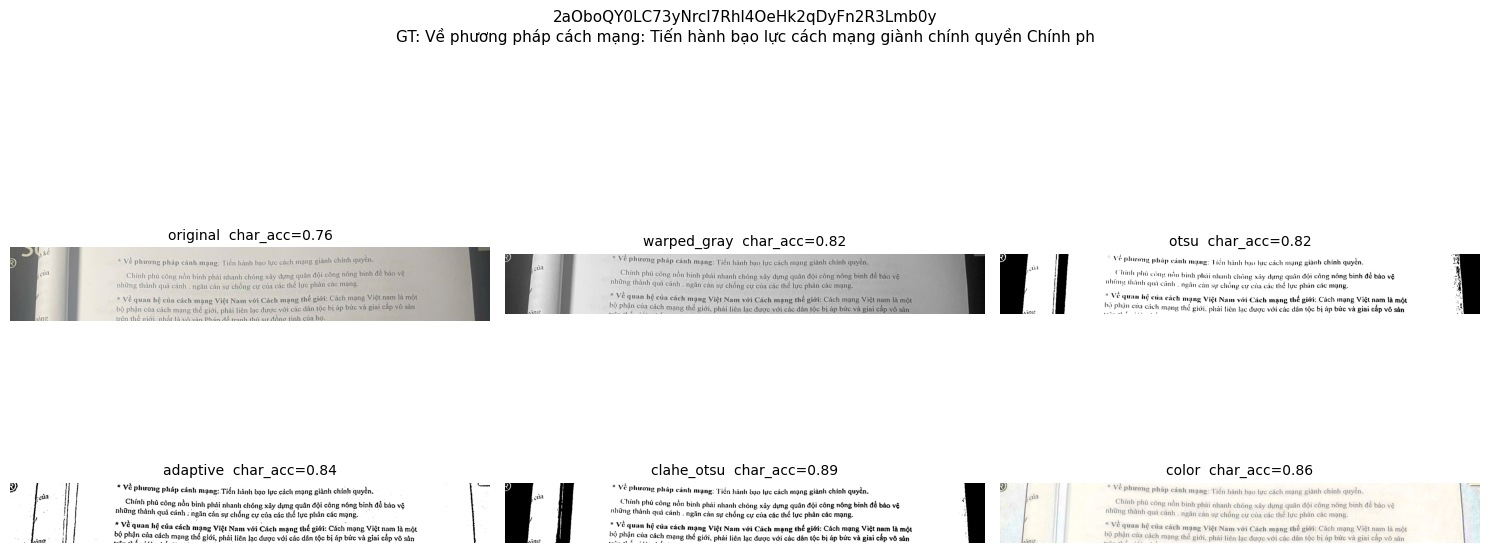

=== 2aOboQY0LC73yNrcl7Rhl4OeHk2qDyFn2R3Lmb0y ===
GT  : Về phương pháp cách mạng: Tiến hành bạo lực cách mạng giành chính quyền Chính phủ công dồ binh phải nhanh chóng xây dựng quân đội công nông binh để bảo vệ những thành quả cánh ngăn cản sự chống cự của các thế lực phản cách mạng Về quan hệ của cách mạng Việt Nam bới Cách mạng thế giới: Cách mạng Việt Nam là một bộ phận của cách mạng thế giới, phải liên tục được với các dân tộc bị áp bức và giai cấp vô sản
  original      : yy ke | à | R) * Ve phương pháp cánh mạng: Tiến hành bạo lực cách mang giành chính quyên. T | ua ` e
  warped_gray   : om) | * Về ‹ es 7 x lại | bộ | Về phương pháp cánh mạng: Tiên hành bạo lực cách mạng giành chính quy
  otsu          : 1 | ve ị sa : š tả | là | VỆ phương pháp cảnh mạng: Tiên hành bạo lực cách mạng giành chính quyền. 2
  adaptive      : Sere | x - ằ 5 as 5 | 3) * VỀ phương pháp cánh mạng:,Tiến hành bạo lực cách mạng piảnh chính quyền. 
  clahe_otsu    : bộ, * VỀ phương pháp cánh mạng: Tiến hành b

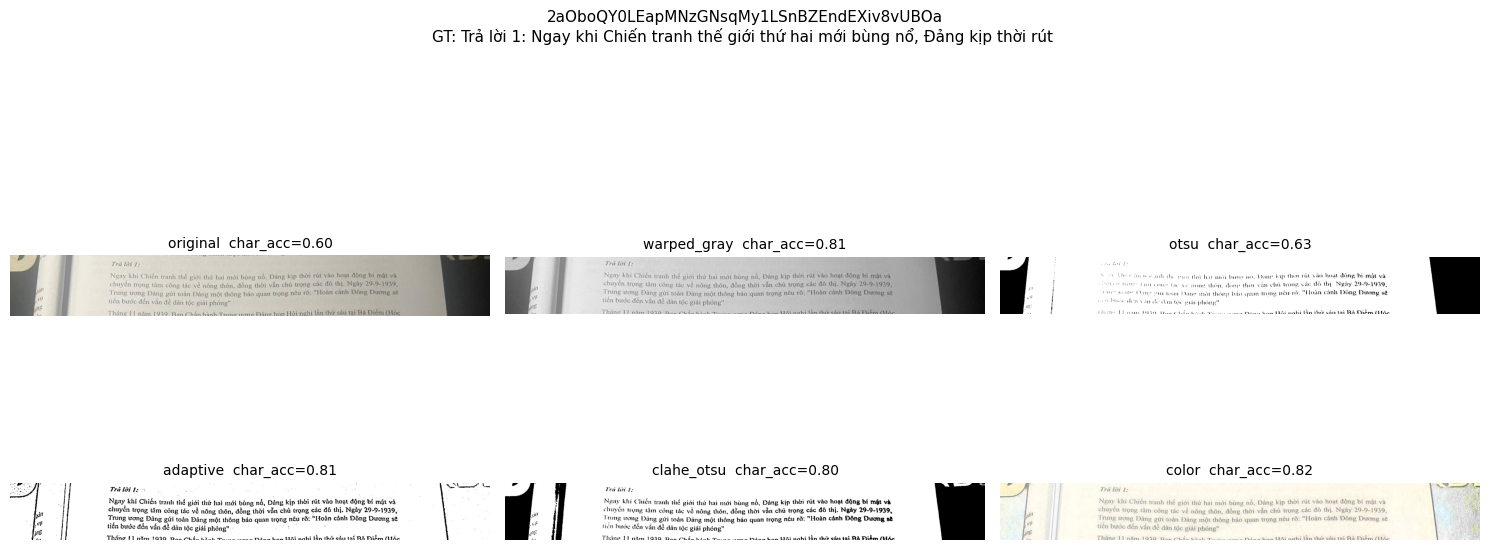

=== 2aOboQY0LEapMNzGNsqMy1LSnBZEndEXiv8vUBOa ===
GT  : Trả lời 1: Ngay khi Chiến tranh thế giới thứ hai mới bùng nổ, Đảng kịp thời rút vào hoạt động bí mật và chuyển trọng tâm công tác về nông thôn, đồng thời vẫn chú trọng các đô thị. Ngày 29-9-1939, trung ương Đảng gửi toàn Đảng một thông báo quan trọng nêu rõ: Hoàn cảnh Đông Dương sẽ tiến bước đến vấn đề dân tộc giải phóng
  original      : Si I ra loi 1: | i ì ee | ào hoạt động bi mật và | | Ngay khi Chiến tranh thế giới thứ hai mới bùng 
  warped_gray   : ats ' | | Ngay khi Chiến tranh thế pidi thir hai méi bang n6, Dang kip théi rut vao hoat dong bi mt 
  otsu          : ” ` | : Now Rie Cro sanh the mái tis harmed bang nd, Bane kip ther rit yao haat dong bi mat và | im 
  adaptive      : we A a a `. ee” AL | ed Tra toile - . X—— a | , Ngay khi Chiến tranh thế giới thứ hai mới bùng nỗ, D
  clahe_otsu    : rr " ” xa. | Tra lot ds | Ỹ Ngày khi Chiến tranh thể giới thứ hai mới bùng nỗ, Dâng kịp thời rút vào
  color         : See: Trả 

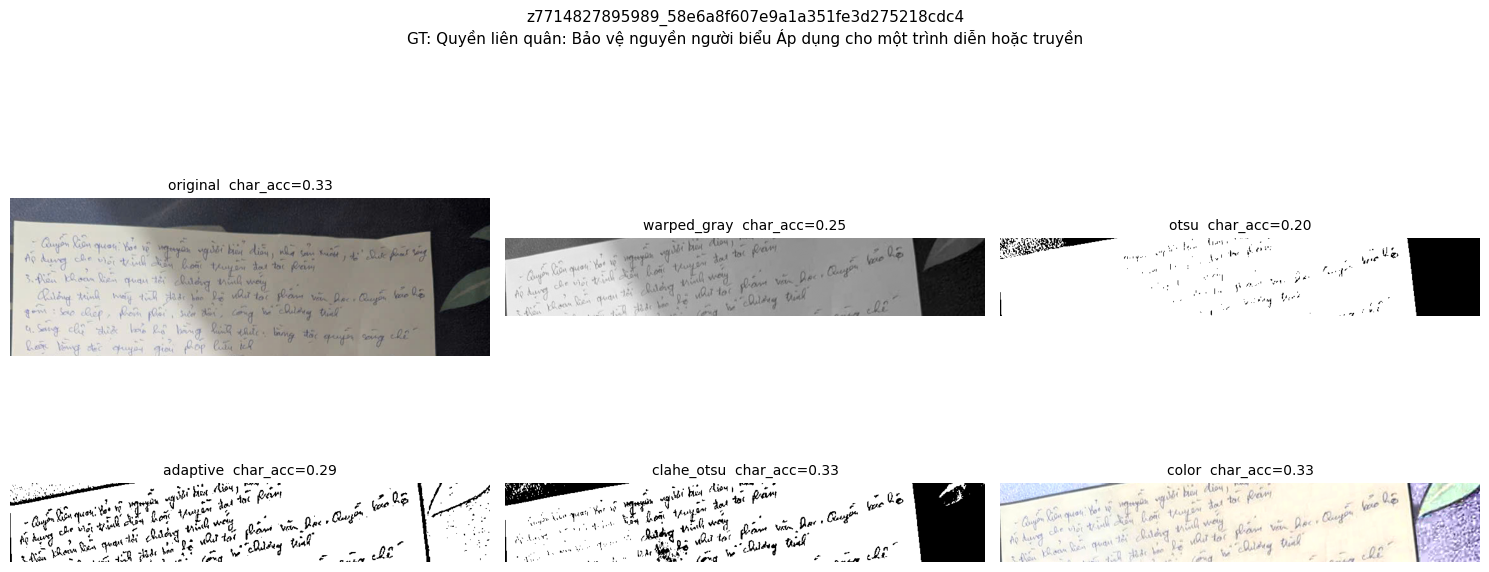

=== z7714827895989_58e6a8f607e9a1a351fe3d275218cdc4 ===
GT  : Quyền liên quân: Bảo vệ nguyền người biểu Áp dụng cho một trình diễn hoặc truyền đạt tác phẩm Điều khoản kiên quan tới chương trình máy được bảo vệ như tác phẩm văn học. Quyền bảo hộ công bố chương trình
  original      : r | ! : tr SG Ewe | Tyee sgt bite chic» ne cá Xe, , 2! 00/2/67 at | 1 Cox duy 3vi oe Pele | Skit Wot
  warped_gray   : bị s06 | NHÀ Ì | day ee | t lại án | 3 V “ 7 | - vÑ te đua» win Be & e or | ns CNG taÍ
  otsu          : Soe Ate | THANH | rege Be ae | vẽ (ay foe | „1 1 | | ¬ pace # ~ r we | nae ga?
  adaptive      : Ad ante we tes toe PO" | oft wa ye ĐC zeae \ fe | fe ie sean deg a as from và» De , 0" tư, : | 2a nh
  clahe_otsu    : a, gti be ON pany | `.“ pee | ván h "`? Ange 3 ‹ : 6 bu we be 3 | fete Tố “ joe in Dee | po ag are B
  color         : oo | - 0, đột mm vu Se dục V262 |  | | & io che Vist ek x (uất W3 tot ape POM | <i MT 499) yk leg ad



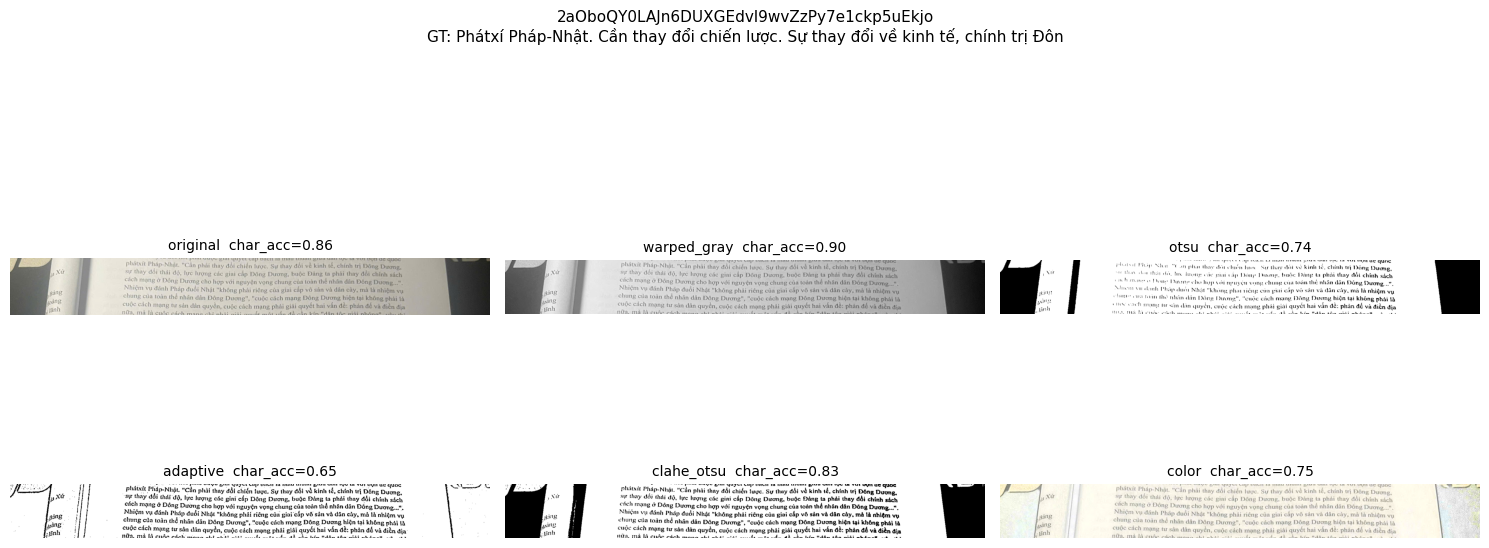

=== 2aOboQY0LAJn6DUXGEdvl9wvZzPy7e1ckp5uEkjo ===
GT  : Phátxí Pháp-Nhật. Cần thay đổi chiến lược. Sự thay đổi về kinh tế, chính trị Đông Dương. Sự thay đổi thái độ, lực lượng các giai cấp Đông Dương, buộc Đảng ta phải thay đổi chính sách cách mạng ở Đông Dương cho hợp với nguyện vọng chưng của toàn thể nhân dân Đông Dương... Nhiệm vụ đánh Pháp đuổi Nhật không phải riêng của giai cấp vô sản và dân cày, mà là nhiệm vụ chung của toàn thể nhân đân Đông Dương, cuộc cách mạng Đông Dương hiện tại không phải là cuộc cách mạng tư sản dân quyền, cuộc cách mạng phải giải quyết hai vấn đề: phản đề và điền địa
  original      : CÔ CÁ Có ỐC lƯ6PG g6 v Ệ vn 0M... HÀ meee ee | phátxít Pháp-Nhật, "Cần phải thay đổi chiến lược, Sự 
  warped_gray   : phátxít Pháp-Nhật. "Cần phải thay đổi chiến lược. Sự thay đổi về kinh tế, chính trị Đông Dương, |  |
  otsu          : Pst Php Nhat “Cám phát thấy đổi chiến Bước Su thay đối về kinh tế, chính try Dang Dương, |  | Xử MA.
  adaptive      : /——— phátxÍt Pháp-Nh

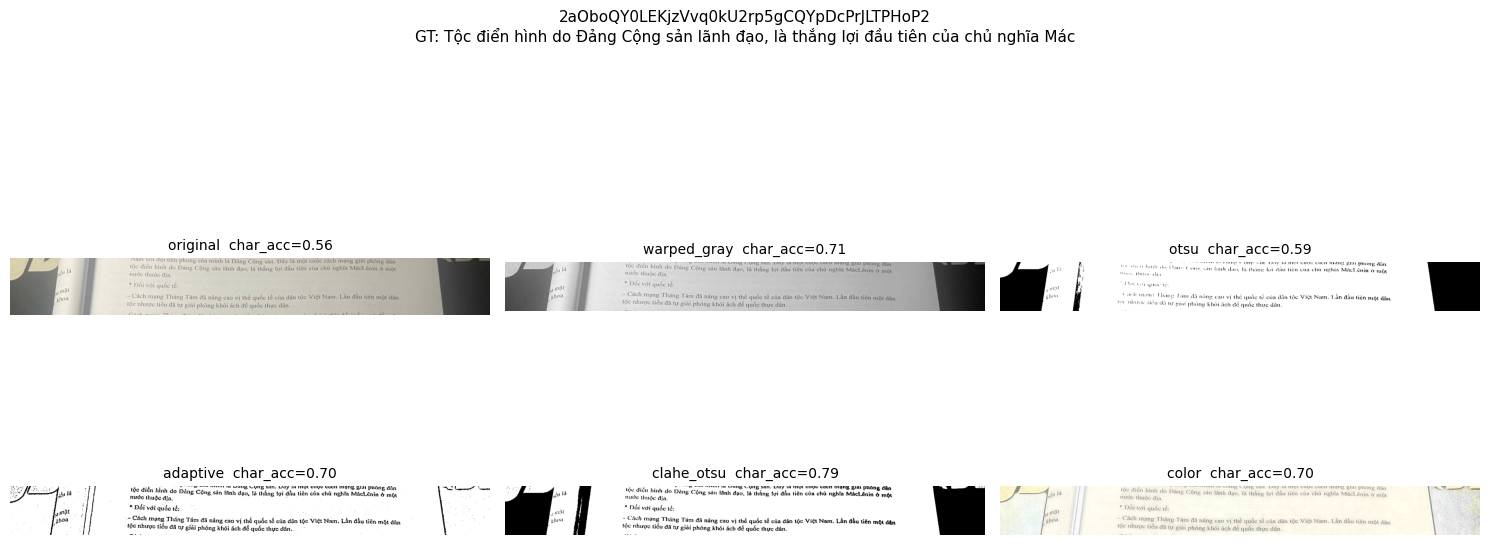

=== 2aOboQY0LEKjzVvq0kU2rp5gCQYpDcPrJLTPHoP2 ===
GT  : Tộc điển hình do Đảng Cộng sản lãnh đạo, là thắng lợi đầu tiên của chủ nghĩa MácLênin ở nước thuộc địa Đối với quốc tế Cách mạng Tháng Tám đã nâng cao vị thế quốc tế của dân tộc Việt Nam. Lần đầu tiên một dân tộc nhược tiểu đã tự giải phòng khỏi ác đế quốc thực dân
  original      : : w } Nam voi d | ìm với đội tiên phong c Ộ | F 157 1ï! : tong của mình là Dang Cộng sân. Đây là một
  warped_gray   : SA NE ONE San. DY IA UV CUCCCAC/I1100QV,... lăn | vệ ‘ee điền hình do Đảng Cộng sản lãnh đạo, là thẳ
  otsu          : CA cố vu SOIREE COTE SAT ĐI HÀ HHẠP GUỐC CịCH THANH Bun phòng đân | hỐ bf e Rink elo Bane Cong sci L
  adaptive      : dài - aver ]— | ep EEN ES A Wg san. Diy ia mot cage each mạng giải phòng, đân ¬ ————. | eet fs od : 
  clahe_otsu    : p Gc didn Winh «ln man Ha UB MON san. Day ta mot cage cách mộng, giải phóng dân xa. | a fe la tộc đi
  color         : `¿:‹ A aw ¬ Aiea 0224155 3c (8-0 sản. eee A OO 02 ý ote ORE UW “ii

In [ ]:
for stem, cache in predictions_cache.items():
    crops = cache['crops']
    preds = cache['preds']
    gt_text = items[stem]['ground_truth']

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    axes = axes.flatten()

    for ax, variant in zip(axes, ALL_VARIANTS):
        img = crops.get(variant)
        if img is None or img.size == 0:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')
            continue
        if len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        row = df[(df['stem'] == stem) & (df['variant'] == variant)]
        acc = row['char_acc'].iloc[0] if len(row) else 0.0
        ax.set_title(f'{variant}  char_acc={acc:.2f}', fontsize=10)
        ax.axis('off')

    plt.suptitle(f'{stem}\nGT: {gt_text[:80]}', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'=== {stem} ===')
    print(f'GT  : {gt_text}')
    for variant in ALL_VARIANTS:
        pred = preds.get(variant, '').strip().replace('\n', ' | ')
        print(f'  {variant:14s}: {pred[:100]}')
    print()

## 10. Lưu kết quả

In [ ]:
tesseract_summary_path = EVAL_DIR / 'ocr_summary_tesseract.csv'
if tesseract_summary_path.exists():
    tesseract_df = pd.read_csv(tesseract_summary_path)
    merged = pd.concat([summary, tesseract_df], ignore_index=True)

    pivot_char = merged.pivot(index='variant', columns='engine', values='char_acc').reindex(variant_order)
    pivot_char['mean'] = pivot_char.mean(axis=1).round(4)
    print('Char Accuracy (cả 2 engine):')
    display(pivot_char.round(4))

    merged.to_csv(EVAL_DIR / 'ocr_summary_combined.csv', index=False)
    print(f'\nLưu combined → {EVAL_DIR / "ocr_summary_combined.csv"}')
else:
    print('Sau khi chạy xong, chạy lại cell này để có bảng tổng hợp.')